In [101]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import optuna
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

In [102]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [103]:
train_data = pd.read_csv(r"C:\Learning_ML\DL_projects\Fashion_MNIST\fashionmnist\versions\4\fashion-mnist_train.csv")
test_data = pd.read_csv(r"C:\Learning_ML\DL_projects\Fashion_MNIST\fashionmnist\versions\4\fashion-mnist_test.csv")

In [104]:
train_data.head(10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,5,4,5,5,3,5,...,7,8,7,4,3,7,5,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,14,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,3,2,0,...,1,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,203,214,166,0,0,0,0,0,0,0


In [105]:
print(train_data.shape)
print(test_data.shape)

(60000, 785)
(10000, 785)


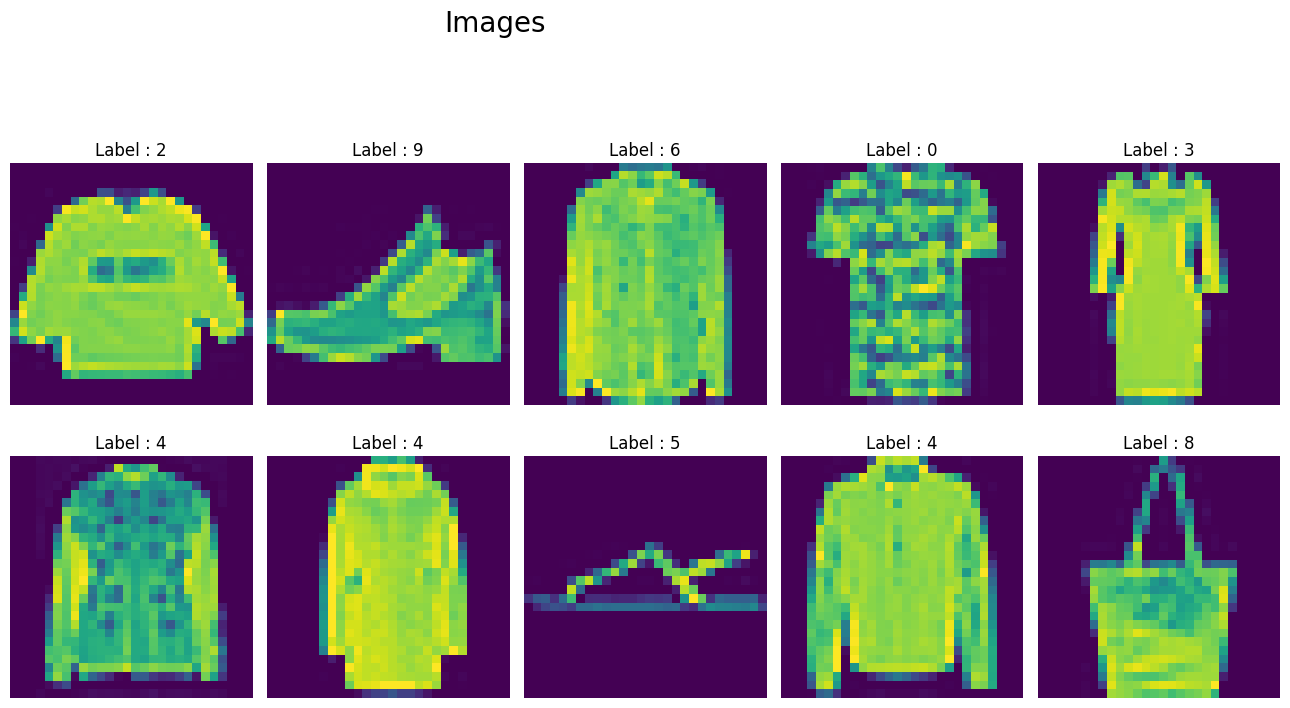

In [106]:
figs, axis = plt.subplots(2,5, figsize=(10, 8))
figs.suptitle("Images", fontsize=20)
for i, ax in enumerate(axis.flat):
    img = train_data.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Label : {train_data.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1.3,0.96])
plt.show()

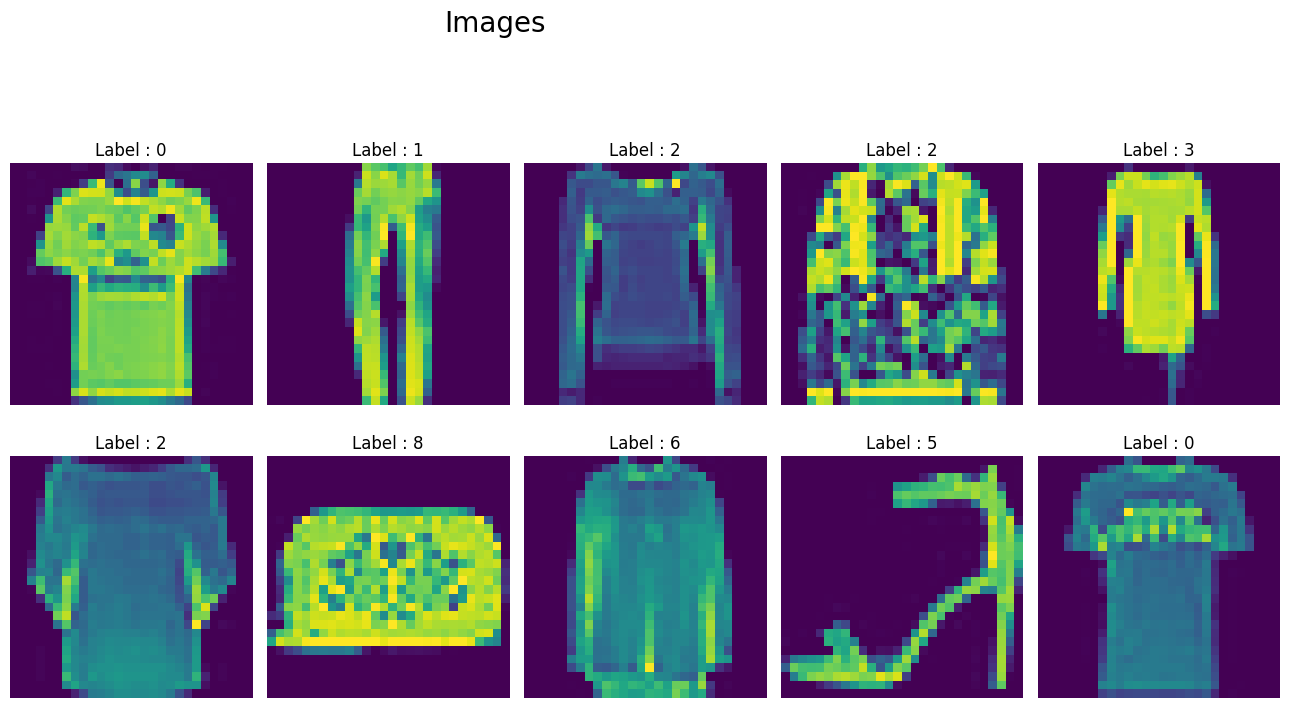

In [107]:
figs, axis = plt.subplots(2,5, figsize=(10, 8))
figs.suptitle("Images", fontsize=20)
for i, ax in enumerate(axis.flat):
    img = test_data.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Label : {test_data.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1.3,0.96])
plt.show()

In [108]:
xtrain = train_data.iloc[:, 1:].to_numpy(dtype=np.float32) / 255.0
ytrain = train_data.iloc[:, 0].to_numpy(dtype=np.int64)
xtest = test_data.iloc[:, 1:].to_numpy(dtype=np.float32) / 255.0
ytest = test_data.iloc[:, 0].to_numpy(dtype=np.int64)

In [109]:
x_train, x_val, y_train, y_val = train_test_split(xtrain, ytrain, test_size=0.1667, random_state=42, stratify=ytrain)

In [110]:
class CustomData(Dataset):
    def __init__(self, features, labels, augment=False):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.augment = augment
    def __len__(self):
        return len(self.features)
    def __getitem__(self, idx):
        img = self.features[idx].view(1, 28, 28)
        if self.augment:
            img = self._augment(img)
        return img.flatten(), self.labels[idx]
    @staticmethod
    def _augment(img):
        if torch.rand(1).item() < 0.5:
            img = torch.flip(img, dims=[2])
        # Small random rotation via affine_grid (cheap, no PIL round-trip)
        if torch.rand(1).item() < 0.5:
            angle = (torch.rand(1).item() - 0.5) * 20 * (np.pi / 180)  # +/-10 deg
            theta = torch.tensor([[np.cos(angle), -np.sin(angle), 0], [np.sin(angle),  np.cos(angle), 0]], dtype=torch.float32)
            grid = torch.nn.functional.affine_grid(theta.unsqueeze(0), [1, 1, 28, 28], align_corners=False)
            img = torch.nn.functional.grid_sample(img.unsqueeze(0), grid, align_corners=False).squeeze(0)
        return img

In [111]:
training = CustomData(x_train, y_train, augment=True)
validation = CustomData(x_val, y_val, augment=False)
testing = CustomData(xtest, ytest, augment=False)

In [112]:
class CNN(nn.Module):
    def __init__(self, dropout, hidden_layer, input_dim, output_dim, neuron_per_layer):
        super().__init__()

        layers = []
        for i in range(hidden_layer):
            layers.append(nn.Conv2d(input_dim, neuron_per_layer, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(neuron_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))
            layers.append(nn.Dropout2d(dropout))
            input_dim = neuron_per_layer
        
        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(neuron_per_layer, output_dim)

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [113]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None, scheduler=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
 
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
 
        with torch.set_grad_enabled(train_mode):
            with torch.autocast(device_type="cuda", enabled=USE_AMP):
                out = model(xb)
                loss = criterion(out, yb)
 
            if train_mode:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                if scheduler is not None:
                    scheduler.step()
 
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += yb.size(0)
 
    return total_loss / total, correct / total

In [114]:
def objective(trial):
    hidden_layer = trial.suggest_int("hidden_layer", 2, 4)          # 5 layers of pooling collapses 28x28 too far
    neuron_per_layer = trial.suggest_int("neuron_per_layer", 16, 128, step=8)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.1)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
 
    train_load = DataLoader(training, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_load = DataLoader(validation, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
 
    model = CNN(dropout, hidden_layer, input_dim=1, output_dim=10, neuron_per_layer=neuron_per_layer).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = (optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay) if optimizer_name == "Adam" else optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay))
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
 
    n_epochs = 6
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=len(train_load), epochs=n_epochs)
 
    for epoch in range(n_epochs):
        run_epoch(model, train_load, criterion, optimizer, scaler, scheduler)
        _, val_acc = run_epoch(model, val_load, criterion)
 
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
 
    return val_acc

In [115]:
if __name__ == "__main__":
    study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
    study.optimize(objective, n_trials=30)
 
    print("Best trial:", study.best_trial.params)
    print("Best val accuracy:", study.best_value)
 
    p = study.best_trial.params
    train_load = DataLoader(training, batch_size=p["batch_size"], shuffle=True, num_workers=0, pin_memory=True)
    val_load = DataLoader(validation, batch_size=p["batch_size"], shuffle=False, num_workers=0, pin_memory=True)
    test_load = DataLoader(testing, batch_size=p["batch_size"], shuffle=False, num_workers=0, pin_memory=True)
 
    model = CNN(p["dropout"], p["hidden_layer"], 1, 10, p["neuron_per_layer"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = (optim.Adam(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"]) if p["optimizer"] == "Adam" else optim.AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"]))
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
 
    final_epochs = 25
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=p["lr"], steps_per_epoch=len(train_load), epochs=final_epochs)
 
    best_val_acc = 0.0
    for epoch in range(final_epochs):
        train_loss, train_acc = run_epoch(model, train_load, criterion, optimizer, scaler, scheduler)
        val_loss, val_acc = run_epoch(model, val_load, criterion)
        best_val_acc = max(best_val_acc, val_acc)
        print(f"Epoch {epoch+1}/{final_epochs}: "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
 
    # Touch the test set exactly once
    test_loss, test_acc = run_epoch(model, test_load, criterion)
    print(f"\nFinal test accuracy: {test_acc:.4f}")

[I 2026-08-16 22:48:31,621] A new study created in memory with name: no-name-7986d4cc-4356-43bb-a147-30d6ab894875
C:\Users\vivek\AppData\Local\Temp\ipykernel_20544\1376116725.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
[I 2026-08-16 22:49:51,560] Trial 0 finished with value: 0.8924215156968607 and parameters: {'hidden_layer': 4, 'neuron_per_layer': 24, 'lr': 0.0008744240401740504, 'dropout': 0.1, 'batch_size': 64, 'optimizer': 'AdamW', 'weight_decay': 8.763848258032747e-05}. Best is trial 0 with value: 0.8924215156968607.
[I 2026-08-16 22:50:44,507] Trial 1 finished with value: 0.6802639472105579 and parameters: {'hidden_layer': 2, 'neuron_per_layer': 88, 'lr': 0.0002840108054830244, 'dropout': 0.30000000000000004, 'batch_size': 256, 'optimizer': 'Adam', 'weight_decay': 0.00018627580027575573}. Best is trial 0 with value: 0.8924215156968607.
[I

Best trial: {'hidden_layer': 4, 'neuron_per_layer': 128, 'lr': 0.006325224850943437, 'dropout': 0.1, 'batch_size': 64, 'optimizer': 'AdamW', 'weight_decay': 0.0009686766761403881}
Best val accuracy: 0.9297140571885623
Epoch 1/25: train_loss=0.5283 train_acc=0.8157 val_loss=0.3456 val_acc=0.8720
Epoch 2/25: train_loss=0.3617 train_acc=0.8681 val_loss=0.3302 val_acc=0.8800
Epoch 3/25: train_loss=0.3291 train_acc=0.8801 val_loss=0.2978 val_acc=0.8878
Epoch 4/25: train_loss=0.3034 train_acc=0.8888 val_loss=0.2775 val_acc=0.8991
Epoch 5/25: train_loss=0.2922 train_acc=0.8932 val_loss=0.2738 val_acc=0.8985
Epoch 6/25: train_loss=0.2795 train_acc=0.8984 val_loss=0.2386 val_acc=0.9140
Epoch 7/25: train_loss=0.2672 train_acc=0.9017 val_loss=0.2512 val_acc=0.9053
Epoch 8/25: train_loss=0.2547 train_acc=0.9067 val_loss=0.2613 val_acc=0.9051
Epoch 9/25: train_loss=0.2424 train_acc=0.9114 val_loss=0.2269 val_acc=0.9163
Epoch 10/25: train_loss=0.2340 train_acc=0.9133 val_loss=0.2390 val_acc=0.9124
E

In [116]:
study.best_value

0.9297140571885623

In [117]:
study.best_params

{'hidden_layer': 4,
 'neuron_per_layer': 128,
 'lr': 0.006325224850943437,
 'dropout': 0.1,
 'batch_size': 64,
 'optimizer': 'AdamW',
 'weight_decay': 0.0009686766761403881}